In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('prj_data.csv')
df.head()

,고객ID,나이,성별,거주지역,가입경로,멤버십등급,월평균구매금액,구매횟수,리뷰점수,쿠폰사용여부,메모,이탈여부
0,C0001,22.0,남,대구,앱,실버,62705.653045,7.0,3.3,N,재구매 유도 대상,1
1,C0002,58.0,여,부산,웹,VIP,180896.754122,18.0,4.7,Y,재구매 유도 대상,0
2,C0003,52.0,여,기타,앱,브론즈,30567.640969,3.0,3.3,Y,NaN,0
3,C0004,40.0,여,경기,앱,실버,71563.606370,3.0,3.8,N,재구매 유도 대상,0
4,C0005,40.0,남,경기,웹,골드,107967.380320,7.0,4.9,N,NaN,0


## 1. 데이터 불러오기 및 결측치 처리

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   고객ID     500 non-null    str    
 1   나이       460 non-null    float64
 2   성별       485 non-null    str    
 3   거주지역     500 non-null    str    
 4   가입경로     480 non-null    str    
 5   멤버십등급    500 non-null    str    
 6   월평균구매금액  500 non-null    float64
 7   구매횟수     500 non-null    float64
 8   리뷰점수     475 non-null    float64
 9   쿠폰사용여부   500 non-null    str    
 10  메모       216 non-null    str    
 11  이탈여부     500 non-null    int64  
dtypes: float64(4), int64(1), str(7)
memory usage: 64.3 KB


In [4]:
df.isnull().sum()

고객ID         0
나이          40
성별          15
거주지역         0
가입경로        20
멤버십등급        0
월평균구매금액      0
구매횟수         0
리뷰점수        25
쿠폰사용여부       0
메모         284
이탈여부         0
dtype: int64

In [5]:
missing_ratio = df.isnull().mean()
missing_ratio

고객ID       0.000
나이         0.080
성별         0.030
거주지역       0.000
가입경로       0.040
멤버십등급      0.000
월평균구매금액    0.000
구매횟수       0.000
리뷰점수       0.050
쿠폰사용여부     0.000
메모         0.568
이탈여부       0.000
dtype: float64

In [6]:
drop_cols = missing_ratio[missing_ratio > 0.5].index.tolist()
df = df.drop(columns=drop_cols)
df

,고객ID,나이,성별,거주지역,가입경로,멤버십등급,월평균구매금액,구매횟수,리뷰점수,쿠폰사용여부,이탈여부
0,C0001,22.0,남,대구,앱,실버,62705.653045,7.0,3.3,N,1
1,C0002,58.0,여,부산,웹,VIP,180896.754122,18.0,4.7,Y,0
2,C0003,52.0,여,기타,앱,브론즈,30567.640969,3.0,3.3,Y,0
3,C0004,40.0,여,경기,앱,실버,71563.606370,3.0,3.8,N,0
4,C0005,40.0,남,경기,웹,골드,107967.380320,7.0,4.9,N,0
...,...,...,...,...,...,...,...,...,...,...,...
495,C0496,39.0,여,경기,웹,골드,108578.954159,9.0,3.5,N,0
496,C0497,24.0,여,대구,광고,브론즈,40162.047877,6.0,3.6,N,1
497,C0498,37.0,남,서울,웹,브론즈,51493.570059,3.0,4.1,Y,0
498,C0499,66.0,여,기타,앱,골드,105068.989111,6.0,4.4,N,0


In [7]:
num_cols_na = df.select_dtypes(include='number').columns
num_cols_na = num_cols_na[df[num_cols_na].isnull().any()]
num_cols_na

Index(['나이', '리뷰점수'], dtype='str')

In [8]:
cat_cols_na = df.select_dtypes(exclude='number').columns
cat_cols_na = cat_cols_na[df[cat_cols_na].isnull().any()]
cat_cols_na

Index(['성별', '가입경로'], dtype='str')

In [10]:
for col in cat_cols_na:
    df[col] = df[col].fillna(df[col].mode()[0])

In [11]:
# 숫자형 컬럼의 결측치를 중앙값으로 채운다.
for c in num_cols_na:
    df[c] = df[c].fillna(df[c].median())

df.isnull().sum() # 모두 0이 나오는지 확인

고객ID       0
나이         0
성별         0
거주지역       0
가입경로       0
멤버십등급      0
월평균구매금액    0
구매횟수       0
리뷰점수       0
쿠폰사용여부     0
이탈여부       0
dtype: int64

## 2. 이상치 탐지 및 처리

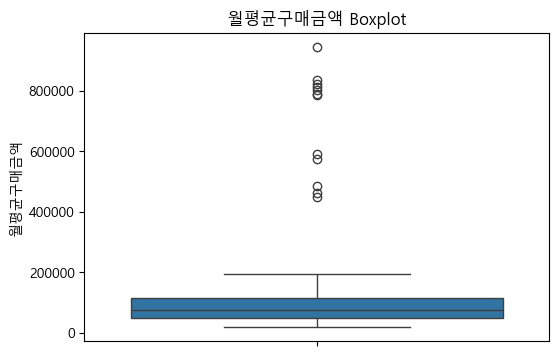

In [12]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['월평균구매금액'])
plt.title('월평균구매금액 Boxplot')
plt.show()

In [13]:
col = '월평균구매금액'
q1 = df[col].quantile(0.25)
q3 = df[col].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
n_outliers

np.int64(12)

In [14]:
# 표본 수가 적을수록 뒤쪽 EDM(그룹 비교)에서 신뢰도가 떨어지므로 표본을 유지하면서
# 극단값만 완화하는 capping이 더 적합하다.
# 이상치 수 -> 12건
df[col] = df[col].clip(lower, upper)
df[col]

0       62705.653045
1      180896.754122
2       30567.640969
3       71563.606370
4      107967.380320
           ...      
495    108578.954159
496     40162.047877
497     51493.570059
498    105068.989111
499     70073.592144
Name: 월평균구매금액, Length: 500, dtype: float64

## 3. 범주형 변수 인코딩

In [15]:
# 인코딩 전 shape / 컬럼 목록
shape_before = df.shape
shape_before


(500, 11)

In [16]:
columns_before = df.columns.tolist()
columns_before

['고객ID',
 '나이',
 '성별',
 '거주지역',
 '가입경로',
 '멤버십등급',
 '월평균구매금액',
 '구매횟수',
 '리뷰점수',
 '쿠폰사용여부',
 '이탈여부']

In [17]:
# 멤버십 등급은 순서의 의미가 있음 -> 레이블 인코딩
# 성별, 거주지역, 가입경로, 쿠폰사용여부는 순서의 의미가 없음 -> 원-핫 인코딩

# sklearn의 LabelEncoder.fit()은 값을 알파벳순으로 자동 정렬하여
#      우리가 원하는 등급 순서(브론즈<실버<골드<VIP)를 보장하지 않는다.
#      따라서 순서를 직접 지정하여 레이블 인코딩을 적용한다.
membership = ['브론즈', '실버', '골드', 'VIP']
membership_map = {label: idx for idx, label in enumerate(membership)}

df['멤버십등급_encoded'] = df['멤버십등급'].map(membership_map)
df = df.drop(columns=['멤버십등급'])

membership_map

{'브론즈': 0, '실버': 1, '골드': 2, 'VIP': 3}

In [18]:
cols = ['성별', '거주지역', '가입경로', '쿠폰사용여부']
df = pd.get_dummies(df, columns=cols)

df.head()

,고객ID,나이,월평균구매금액,구매횟수,리뷰점수,이탈여부,멤버십등급_encoded,성별_남,성별_여,거주지역_경기,거주지역_기타,거주지역_대구,거주지역_부산,거주지역_서울,가입경로_광고,가입경로_앱,가입경로_웹,가입경로_지인추천,쿠폰사용여부_N,쿠폰사용여부_Y
0,C0001,22.0,62705.653045,7.0,3.3,1,1,True,False,False,False,True,False,False,False,True,False,False,True,False
1,C0002,58.0,180896.754122,18.0,4.7,0,3,False,True,False,False,False,True,False,False,False,True,False,False,True
2,C0003,52.0,30567.640969,3.0,3.3,0,0,False,True,False,True,False,False,False,False,True,False,False,False,True
3,C0004,40.0,71563.606370,3.0,3.8,0,1,False,True,True,False,False,False,False,False,True,False,False,True,False
4,C0005,40.0,107967.380320,7.0,4.9,0,2,True,False,True,False,False,False,False,False,False,True,False,True,False


In [19]:
# 인코딩 후
df.shape

(500, 20)

In [20]:
df.columns.tolist()

['고객ID',
 '나이',
 '월평균구매금액',
 '구매횟수',
 '리뷰점수',
 '이탈여부',
 '멤버십등급_encoded',
 '성별_남',
 '성별_여',
 '거주지역_경기',
 '거주지역_기타',
 '거주지역_대구',
 '거주지역_부산',
 '거주지역_서울',
 '가입경로_광고',
 '가입경로_앱',
 '가입경로_웹',
 '가입경로_지인추천',
 '쿠폰사용여부_N',
 '쿠폰사용여부_Y']

## 4. 파생변수 생성 및 스케일링

In [21]:
# 파생변수 1: 건당평균구매금액
df['건당평균구매금액'] = df['월평균구매금액'] / df['구매횟수']

# 파생변수 2: 연령대
bins = [0, 20, 30, 40, 50, 60, 100]
labels = ['10대', '20대', '30대', '40대', '50대', '60대이상']
df['연령대'] = pd.cut(df['나이'], bins=bins, labels=labels)

df[['나이', '연령대', '월평균구매금액', '구매횟수', '건당평균구매금액']].head()

,나이,연령대,월평균구매금액,구매횟수,건당평균구매금액
0,22.0,20대,62705.653045,7.0,8957.950435
1,58.0,50대,180896.754122,18.0,10049.819673
2,52.0,50대,30567.640969,3.0,10189.213656
3,40.0,30대,71563.606370,3.0,23854.535457
4,40.0,30대,107967.380320,7.0,15423.911474


In [22]:
scale_cols = ['나이', '월평균구매금액', '구매횟수', '리뷰점수', '건당평균구매금액']
df[scale_cols]

,나이,월평균구매금액,구매횟수,리뷰점수,건당평균구매금액
0,22.0,62705.653045,7.0,3.3,8957.950435
1,58.0,180896.754122,18.0,4.7,10049.819673
2,52.0,30567.640969,3.0,3.3,10189.213656
3,40.0,71563.606370,3.0,3.8,23854.535457
4,40.0,107967.380320,7.0,4.9,15423.911474
...,...,...,...,...,...
495,39.0,108578.954159,9.0,3.5,12064.328240
496,24.0,40162.047877,6.0,3.6,6693.674646
497,37.0,51493.570059,3.0,4.1,17164.523353
498,66.0,105068.989111,6.0,4.4,17511.498185


In [23]:
df[scale_cols].describe() # 스케일링 전 기술통계량

,나이,월평균구매금액,구매횟수,리뷰점수,건당평균구매금액
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,43.180000,86092.413399,7.822000,3.734800,13129.800389
std,14.384764,47003.366902,4.481795,0.540382,8858.181124
min,18.000000,19127.903927,1.000000,2.500000,2732.557704
25%,32.000000,48362.456334,4.000000,3.400000,8792.086134
50%,43.000000,74770.324856,7.000000,3.700000,10854.226803
75%,56.000000,114551.098353,10.250000,4.100000,13857.202365
max,69.000000,213834.061381,21.000000,5.000000,71278.020460


In [24]:
scaler = StandardScaler()   # 표준화 스케일링
df[scale_cols] = scaler.fit_transform(df[scale_cols])   # 스케일링 학습 및 변환

df[scale_cols].describe() # 스케일링 후 기술통계량

,나이,월평균구매금액,구매횟수,리뷰점수,건당평균구매금액
count,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02
mean,1.776357e-18,7.815970e-17,-2.842171e-17,-6.359357e-16,1.127987e-16
std,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00
min,-1.752216e+00,-1.426102e+00,-1.523682e+00,-2.287338e+00,-1.174920e+00
25%,-7.779896e-01,-8.035115e-01,-8.536373e-01,-6.201819e-01,-4.901749e-01
50%,-1.252577e-02,-2.411195e-01,-1.835923e-01,-6.446335e-02,-2.571468e-01
75%,8.921133e-01,6.060669e-01,5.422898e-01,6.764947e-01,8.219864e-02
max,1.796752e+00,2.720435e+00,2.943284e+00,2.343650e+00,6.570926e+00


In [46]:
# 최종 전처리 완료 데이터를 prj_data_cleaned.csv로 저장
df.to_csv('prj_data_cleaned.csv', index=False, encoding='utf-8-sig')
print('저장 완료:', df.shape)

저장 완료: (500, 22)
